https://github.com/NASA-IMPACT/hls-foundation-os/blob/main/exploration.ipynb

In [1]:
!apt-get update && apt-get install git-lfs -y
!git lfs install
!cd "data/" && git clone "https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M" && cd -

Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Fetched 384 kB in 1s (448 kB/s)    
Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 71 not upgraded.
Git LFS initialized.
Cloning into 'Prithvi-EO-2.0-300M'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 59 (delta 19), reused 0 (delta 0), pack-reused 4 (from 1)
Unpacking objects: 100% (59/59), 1.46 MiB | 20.21 MiB/s, done.
Encountered 1 file(s

In [2]:
!uv pip install -r "data/Prithvi-EO-2.0-300M/requirements.txt"

Audited 5 packages in 30ms


In [3]:
import sys
sys.path.append("data/Prithvi-EO-2.0-300M/")

In [72]:
import os
from os.path import join
from pathlib import Path
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import json
from tqdm.auto import tqdm

from prithvi_mae import PrithviMAE

NO_DATA = -9999
NO_DATA_FLOAT = 0.0001
PERCENTILES = (0.1, 99.9)
DEVICE = "cuda"

In [13]:
def load_raster(path, crop=None):
    with rasterio.open(path) as src:
        img = src.read()

        # load first 6 bands
        img = img[:6]

        img = np.where(img == NO_DATA, NO_DATA_FLOAT, img)
        if crop:
            img = img[:, -crop[0]:, -crop[1]:]
    return img

def enhance_raster_for_visualization(raster, ref_img=None):
    if ref_img is None:
        ref_img = raster
    channels = []
    for channel in range(raster.shape[0]):
        valid_mask = np.ones_like(ref_img[channel], dtype=bool)
        valid_mask[ref_img[channel] == NO_DATA_FLOAT] = False
        mins, maxs = np.percentile(ref_img[channel][valid_mask], PERCENTILES)
        normalized_raster = (raster[channel] - mins) / (maxs - mins)
        normalized_raster[~valid_mask] = 0
        clipped = np.clip(normalized_raster, 0, 1)
        channels.append(clipped)
    clipped = np.stack(channels)
    channels_last = np.moveaxis(clipped, 0, -1)[..., :3]
    rgb = channels_last[..., ::-1]
    return rgb

In [14]:
def plot_image_mask_reconstruction(normalized, mask_img, pred_img):
    # Mix visible and predicted patches
    rec_img = normalized.clone()
    rec_img[mask_img == 1] = pred_img[mask_img == 1]  # binary mask: 0 is keep, 1 is remove

    mask_img_np = mask_img.numpy().reshape(6, 224, 224).transpose((1, 2, 0))[..., :3]

    rec_img_np = (rec_img.numpy().reshape(6, 224, 224) * stds) + means
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 6))

    for subplot in ax:
        subplot.axis('off')

    ax[0].imshow(enhance_raster_for_visualization(input_data))
    masked_img_np = enhance_raster_for_visualization(input_data).copy()
    masked_img_np[mask_img_np[..., 0] == 1] = 0
    ax[1].imshow(masked_img_np)
    ax[2].imshow(enhance_raster_for_visualization(rec_img_np, ref_img=input_data))

In [5]:
root = Path("data/Prithvi-EO-2.0-300M/")

In [12]:
# load weights
weights_path = root / "Prithvi_EO_V2_300M.pt"
checkpoint = torch.load(weights_path, map_location="cpu")

# read model config
model_cfg_path = root / "config.json"
with open(model_cfg_path) as f:
    model_config = json.load(f)

# let us use only 1 frame for now (the model was trained on 3 frames)
model_config["num_frames"] = 1

# instantiate model
model = PrithviMAE(**model_config["pretrained_cfg"])
model.eval()

# load weights into model
# strict=false since we are loading with only 1 frame, but the warning is expected
del checkpoint['encoder.pos_embed']
del checkpoint['decoder.decoder_pos_embed']

_ = model.load_state_dict(checkpoint, strict=False)

/tmp/ipykernel_1098/492012563.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weights_path, map_location="cpu")


Input data shape is (6, 224, 224)


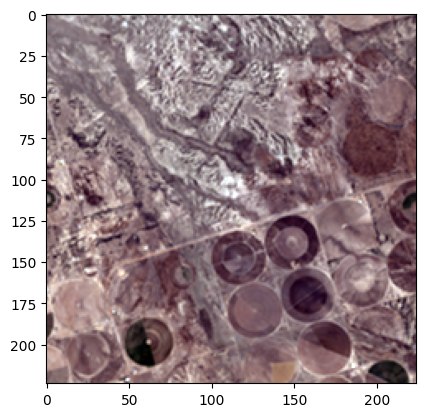

In [16]:
raster_path = "data/Prithvi-100M/examples/HLS.L30.T13REN.2018013T172747.v2.0.B02.B03.B04.B05.B06.B07_cropped.tif"
input_data = load_raster(raster_path, crop=(224, 224))
print(f"Input data shape is {input_data.shape}")
raster_for_visualization = enhance_raster_for_visualization(input_data)
plt.imshow(raster_for_visualization)

In [19]:
# statistics used to normalize images before passing to the model
means = np.array(model_config["pretrained_cfg"]["mean"]).reshape(-1, 1, 1)
stds = np.array(model_config["pretrained_cfg"]["std"]).reshape(-1, 1, 1)

def preprocess_image(image):
    # normalize image
    C, H, W = image.shape
    normalized = image.copy()
    normalized = ((image - means) / stds)
    normalized = normalized.reshape(1, C, 1, H, W)
    normalized = torch.from_numpy(normalized).to(torch.float32)
    return normalized

In [20]:
normalized = preprocess_image(input_data)
with torch.inference_mode():
    mask_ratio = 0.5
    _, pred, mask = model(normalized, mask_ratio=mask_ratio)
    mask_img = model.unpatchify(mask.unsqueeze(-1).repeat(1, 1, pred.shape[-1])).detach().cpu()
    pred_img = model.unpatchify(pred).detach().cpu()

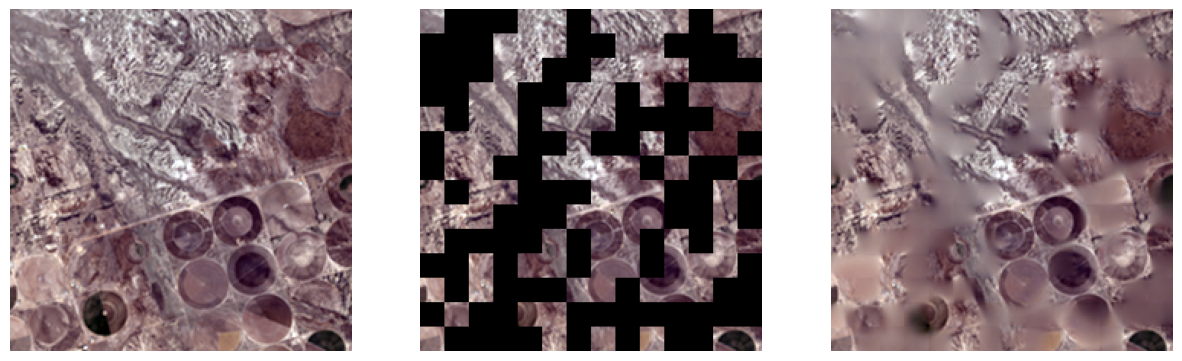

In [21]:
plot_image_mask_reconstruction(normalized, mask_img, pred_img)

In [34]:
# if going with plain pytorch:
# - remember to normalize images beforehand (find the normalization statistics in the config file)
# - turn off masking by passing mask_ratio = 0
with torch.inference_mode():
    normalized = preprocess_image(input_data)
    features_all = model.forward_features(normalized)

In [23]:
input_data.shape, normalized.shape

((6, 224, 224), torch.Size([1, 6, 1, 224, 224]))

In [26]:
len(features_all), [f.shape for f in features_all]

(24,
 [torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024]),
  torch.Size([1, 197, 1024])])

In [115]:
def features_to_embedding(features: list["torch.Tensor"]) -> "torch.Tensor":
    return features[-1][:, -1, :].squeeze()

In [116]:
features_to_embedding(features_all)

tensor([ 0.2031, -0.1277,  0.0690,  ...,  0.6901,  0.0879,  0.0903])

In [45]:
# chips_dict = torch.load("data/chips_s2_pkflood.pt")
chips = chips_dict["chips"]
dates = chips_dict["dates"]

In [46]:
chips.shape

(346, 512, 512, 12)

In [80]:
chips = chips[..., 1:7]
chips.shape

(346, 6, 512, 512)

In [ ]:
chips_normalized = (chips - means.squeeze()) / stds.squeeze()
chips_normalized = chips_normalized.transpose(0, 3, 1, 2)
chips_normalized.shape

In [ ]:
emb_dims = 1024

In [90]:
class ChipDataset:
    def __init__(self, chips):
        self.chips = chips
        
    def __getitem__(self, i):
        return self.chips[i], torch.nan

    def __len__(self):
        return len(self.chips)

In [91]:
ds = ChipDataset(chips_normalized)
dl = DataLoader(ds, batch_size=4, num_workers=0, shuffle=False, pin_memory=True)

In [67]:
model = model.to(DEVICE)

In [117]:
emb_dims = 1024
embeddings = torch.zeros(len(ds), emb_dims)

i = 0
with torch.inference_mode(), tqdm(dl, desc='Creating embeddings') as bar:
    for x, _ in bar:
        x = x.unsqueeze(2).float()
        x = x.to(DEVICE)
        emb = features_to_embedding(model.forward_features(x))
        embeddings[i:i + len(x)] = emb.cpu()
        i += len(x)

Creating embeddings:   0%|          | 0/87 [00:00<?, ?it/s]

In [106]:
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns
sns.reset_defaults()

In [102]:
t_doy = np.array([datetime.strptime(date, '%Y-%m-%d').timetuple().tm_yday for date in dates])
t_foy = np.clip(t_doy / 365, 0, 1)

In [118]:
embeddings -= embeddings.mean(axis=0)

In [119]:
from sklearn.decomposition import PCA

pca = PCA(whiten=True)
pca.fit(embeddings)
pca_emb = pca.transform(embeddings)
pca_emb.shape

(346, 346)

In [120]:
from sklearn.linear_model import RANSACRegressor
from matplotlib.colors import Normalize

def t_to_feats(t):
    feat_1 = np.sin(t * np.pi * 2)
    feat_2 = np.cos(t * np.pi * 2)
    return np.stack([feat_1, feat_2], axis=1)

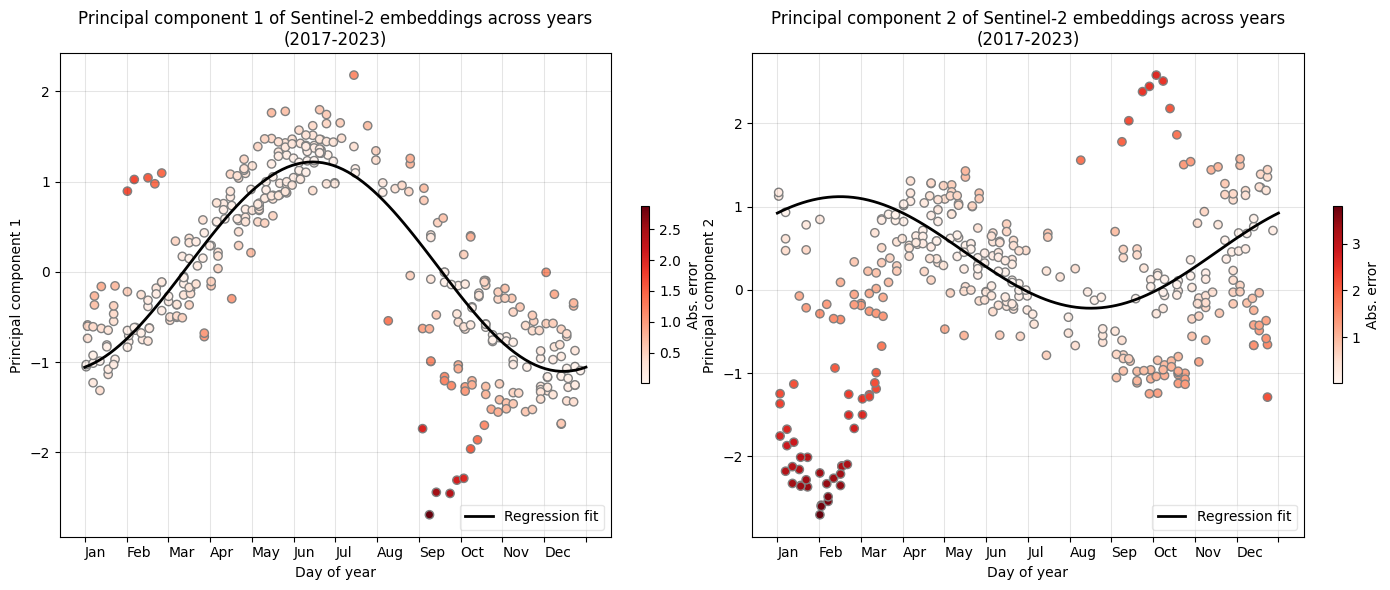

In [121]:
plt.close('all')
fig, axs = plt.subplots(1, 2, figsize=(14, 6), squeeze=True, tight_layout=True)
cmap = plt.get_cmap('Reds')

for pc, ax in enumerate(axs.flat):
    lr = RANSACRegressor()
    Y = pca_emb[:, pc]
    X = t_to_feats(t_foy)
    _ = lr.fit(X, Y)

    x = t_foy
    y_pred = lr.predict(t_to_feats(x))
    error = np.abs(y_pred - pca_emb[:, pc])
    norm = Normalize(error.min(), error.max())
    cols = cmap(norm(error))
    ax.scatter(x, pca_emb[:, pc], c=cols, ec='gray', alpha=1)

    t = np.linspace(0, 1, 100)
    x = t_to_feats(t)
    y_pred = lr.predict(x)
    ax.plot(t, y_pred, lw=2, c='k', label='Regression fit')
    ax.legend(loc='lower left')
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    # sm.set_array([])
    plt.colorbar(sm, ax=ax, fraction=0.015, label='Abs. error')
    
    ax.legend(loc='lower right', framealpha=0.5)
    ax.grid('--', c='k', alpha=0.1)
    ax.set_xticks(np.arange(0, 13) / 12, 
                  ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', ''])
    for tick in ax.xaxis.get_majorticklabels():
        tick.set_horizontalalignment('left')
    ax.set_title(f'Principal component {pc + 1} of Sentinel-2 embeddings across years\n(2017-2023)')
    ax.set_xlabel('Day of year')
    ax.set_ylabel(f'Principal component {pc + 1}')

plt.show()

In [122]:
dates_flood = np.array([
    '2020-07-15', '2020-09-08', '2020-09-18', '2020-09-23',
    '2020-09-28', '2020-10-03', '2020-10-08', '2020-10-18',
    '2020-10-28', '2022-09-03', '2022-09-08', '2022-09-13',
    '2022-09-23', '2022-09-28', '2022-10-03', '2022-10-08',
    '2022-10-13', '2022-10-18', '2022-10-23', '2022-10-28'
])

def to_t_day(date):
    timetuple = datetime.strptime(date, '%Y-%m-%d').timetuple()
    year = timetuple.tm_year
    doy = np.clip(timetuple.tm_yday / 365, 0, 1)
    return year + doy

t_doy_flood = np.array([datetime.strptime(date, '%Y-%m-%d').timetuple().tm_yday for date in dates_flood])
t_day = np.array([to_t_day(date) for date in dates])
t_day_flood = np.array([to_t_day(date) for date in dates_flood])

In [123]:
pc = 0
lr = RANSACRegressor()
Y = pca_emb[:, pc]
X = t_to_feats(t_foy)
_ = lr.fit(X, Y)

x = t_foy
y_pred = lr.predict(t_to_feats(x))
error = np.abs(y_pred - pca_emb[:, pc])

dates_flood = dates[(t_foy > 0.5) & (error > 1.)]
dates_flood

array(['2020-09-08', '2020-09-08', '2020-09-18', '2020-09-18',
       '2020-09-23', '2020-09-28', '2020-09-28', '2020-10-03',
       '2020-10-03', '2020-10-08', '2020-10-08', '2020-10-18',
       '2022-09-03', '2022-09-08', '2022-09-13', '2022-09-23',
       '2022-09-28', '2022-10-03', '2022-10-08', '2022-10-13',
       '2022-10-18', '2022-10-23', '2022-10-28', '2023-08-09',
       '2023-09-03', '2023-09-08'], dtype='<U10')

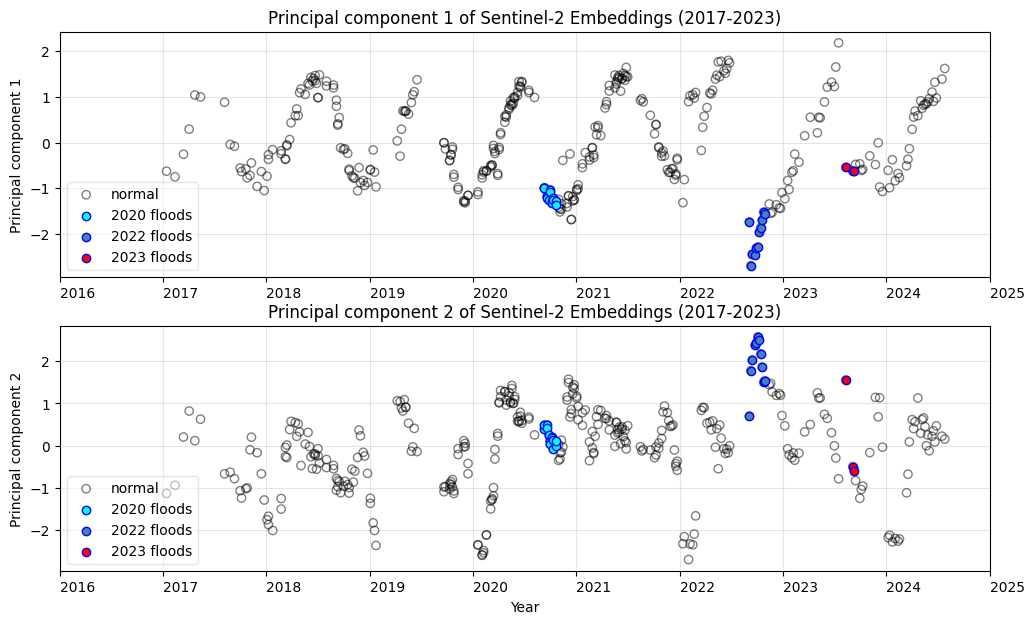

In [124]:
plt.close('all')
fig, axs = plt.subplots(2, 1, figsize=(12, 7), squeeze=True)

for pc, ax in enumerate(axs):
    ax.scatter(t_day, pca_emb[:, pc], ec='k', fc='none', alpha=0.5, label='normal')
    
    flood_dates_2020 = set([date for date in dates_flood if date.startswith('2020')])
    flood_inds_2020 = np.where([date in flood_dates_2020 for date in dates])[0]
    ax.scatter(t_day[flood_inds_2020], pca_emb[flood_inds_2020, pc], ec='b', fc='cyan', label='2020 floods')
    
    flood_dates_2022 = set([date for date in dates_flood if date.startswith('2022')])
    flood_inds_2022 = np.where([date in flood_dates_2022 for date in dates])[0]
    ax.scatter(t_day[flood_inds_2022], pca_emb[flood_inds_2022, pc], ec='b', fc='steelblue', label='2022 floods')
    
    flood_dates_2023 = set([date for date in dates_flood if date.startswith('2023')])
    flood_mask_2023 = np.array([date in flood_dates_2023 for date in dates])
    ax.scatter(t_day[flood_mask_2023], pca_emb[flood_mask_2023, pc], ec='b', fc='red', label='2023 floods')
    
    ax.legend(loc='lower left', framealpha=0.5)
    ax.grid('--', c='k', alpha=0.1)
    ax.set_title(f'Principal component {pc + 1} of Sentinel-2 Embeddings (2017-2023)')
    ax.set_xlim((2016, 2025))
    for tick in ax.xaxis.get_majorticklabels():
        tick.set_horizontalalignment('left')
    ax.set_ylabel(f'Principal component {pc + 1}')
    if pc == len(axs) - 1:
        ax.set_xlabel('Year')

plt.show()

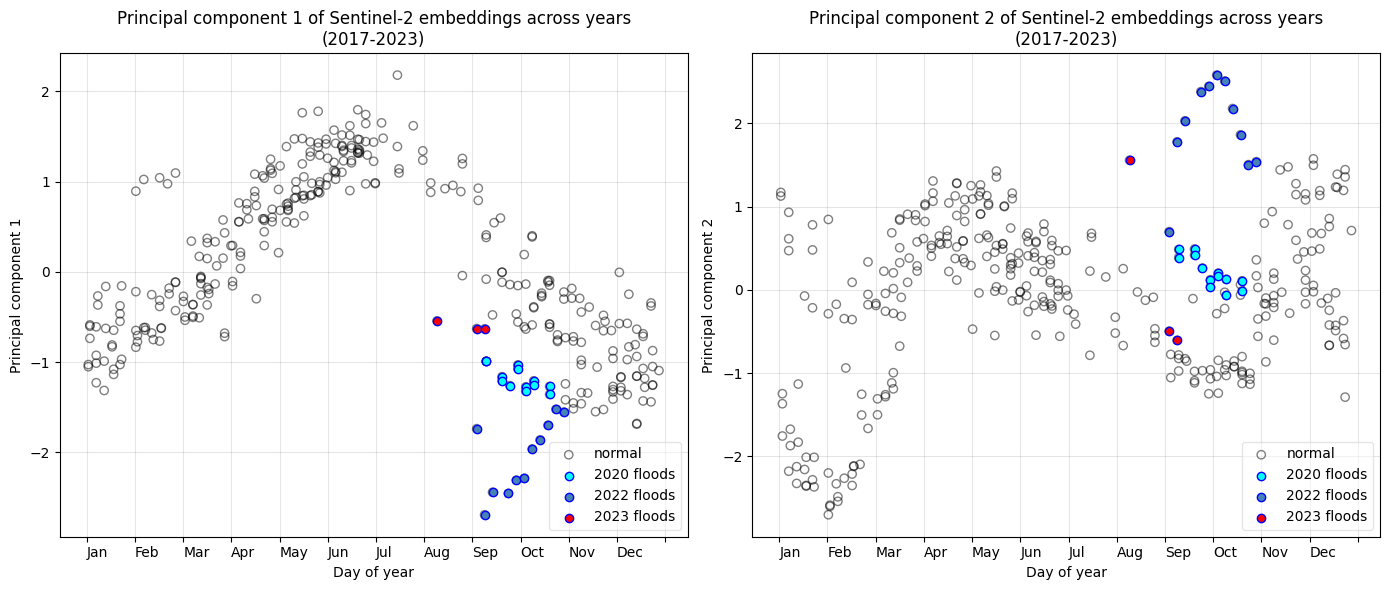

In [125]:
plt.close('all')
fig, axs = plt.subplots(1, 2, figsize=(14, 6), squeeze=True, tight_layout=True)

for pc, ax in enumerate(axs.flat):
    ax.scatter(t_foy, pca_emb[:, pc], ec='k', fc='none', alpha=0.5, label='normal')
    
    flood_dates_2020 = set([date for date in dates_flood if date.startswith('2020')])
    flood_mask_2020 = np.array([date in flood_dates_2020 for date in dates])
    ax.scatter(t_foy[flood_mask_2020], pca_emb[flood_mask_2020, pc], ec='b', fc='cyan', label='2020 floods')
    
    flood_dates_2022 = set([date for date in dates_flood if date.startswith('2022')])
    flood_mask_2022 = np.array([date in flood_dates_2022 for date in dates])
    ax.scatter(t_foy[flood_mask_2022], pca_emb[flood_mask_2022, pc], ec='b', fc='steelblue', label='2022 floods')
    
    flood_dates_2023 = set([date for date in dates_flood if date.startswith('2023')])
    flood_mask_2023 = np.array([date in flood_dates_2023 for date in dates])
    ax.scatter(t_foy[flood_mask_2023], pca_emb[flood_mask_2023, pc], ec='b', fc='red', label='2023 floods')
    
    ax.legend(loc='lower right', framealpha=0.5)
    ax.grid('--', c='k', alpha=0.1)
    ax.set_xticks(np.arange(0, 13) / 12, 
                  ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', ''])
    for tick in ax.xaxis.get_majorticklabels():
        tick.set_horizontalalignment('left')
    ax.set_title(f'Principal component {pc + 1} of Sentinel-2 embeddings across years\n(2017-2023)')
    ax.set_xlabel('Day of year')
    ax.set_ylabel(f'Principal component {pc + 1}')

plt.show()